In [24]:
import pandas as pd
import numpy as np
df = pd.read_csv('Phishing_URL_ds_cleaned.csv')

In [25]:
#we need to drop the high correlated features to avoid multicollinearity issues in modeling
#the problem is that some of these features are important for the model performance even have high correlation we will apply PCA for them later
#we need to drop only useless features that have high correlation and low importance and might be keep same information with other features
# as I check corr matrix in EDA part these features can be dropped safely without losing important information


1. The "URL Length" Cluster (Top-Left Red Block)
The Problem: Look at the top-left of your heatmap. URLLength is almost perfectly correlated with NoOfLettersInURL and strongly correlated with NoOfDegitsInURL.

    Why? Because Length = Letters + Digits + SpecialChars. You are feeding the model the same math equation three times.

    The Fix:

    Keep: URLLength (It measures "Magnitude").

    Keep: LetterRatioInURL, DegitRatioInURL (They measure "Density").

    DROP: NoOfLettersInURL, NoOfDegitsInURL, NoOfOtherSpecialCharsInURL.

2. The "Obfuscation" Trio
    The Problem: There is another tight red cluster between HasObfuscation, NoOfObfuscatedChar, and ObfuscationRatio.

    If ObfuscationRatio > 0, then HasObfuscation is always 1.

    NoOfObfuscatedChar is just Ratio * URLLength.

    The Fix:

    Keep: ObfuscationRatio (Continuous variables are better for PCA/t-SNE than Binary ones).

    DROP: HasObfuscation (Redundant binary flag), NoOfObfuscatedChar (Redundant count).

3. The "Title Match" Redundancy
The Problem: DomainTitleMatchScore and URLTitleMatchScore appear to be highly correlated (the red square in the middle-right).

    Usually, the Domain and the URL share the same title match logic.

    The Fix:

    Keep: URLTitleMatchScore (It is usually more granular).

    DROP: DomainTitleMatchScore.

4. Zero Variance Candidates (The "White" Rows)
    Look at rows like HasFavicon, Robots, or IsResponsive. They seem to have very low correlation (light colors) with almost everything, including the label.

    Check: Run df['HasFavicon'].value_counts(). If 99% of your data is "0", this feature is useless "noise" for t-SNE and should be dropped.

In [26]:
redundant_counts = [
        'NoOfLettersInURL',
        'NoOfDegitsInURL',
        'NoOfOtherSpecialCharsInURL',
        'NoOfObfuscatedChar',
        'NoOfEqualsInURL',  # Usually captured by 'NoOfOtherSpecialChars' or ratios
        'NoOfQMarkInURL',
        'NoOfAmpersandInURL'
    ]
redundant_flags = [
        'HasObfuscation', 
        'HasTitle', # Usually redundant if you have TitleMatchScore
    ]
# Keep URLTitleMatchScore, drop DomainTitleMatchScore (if corr > 0.9)
redundant_scores = ['DomainTitleMatchScore']
all_drops = redundant_counts + redundant_flags + redundant_scores

In [27]:
#drop them from dataframe
cols_to_drop = [c for c in all_drops if c in df.columns] #ensure columns exist
df.drop(columns=cols_to_drop, inplace=True)

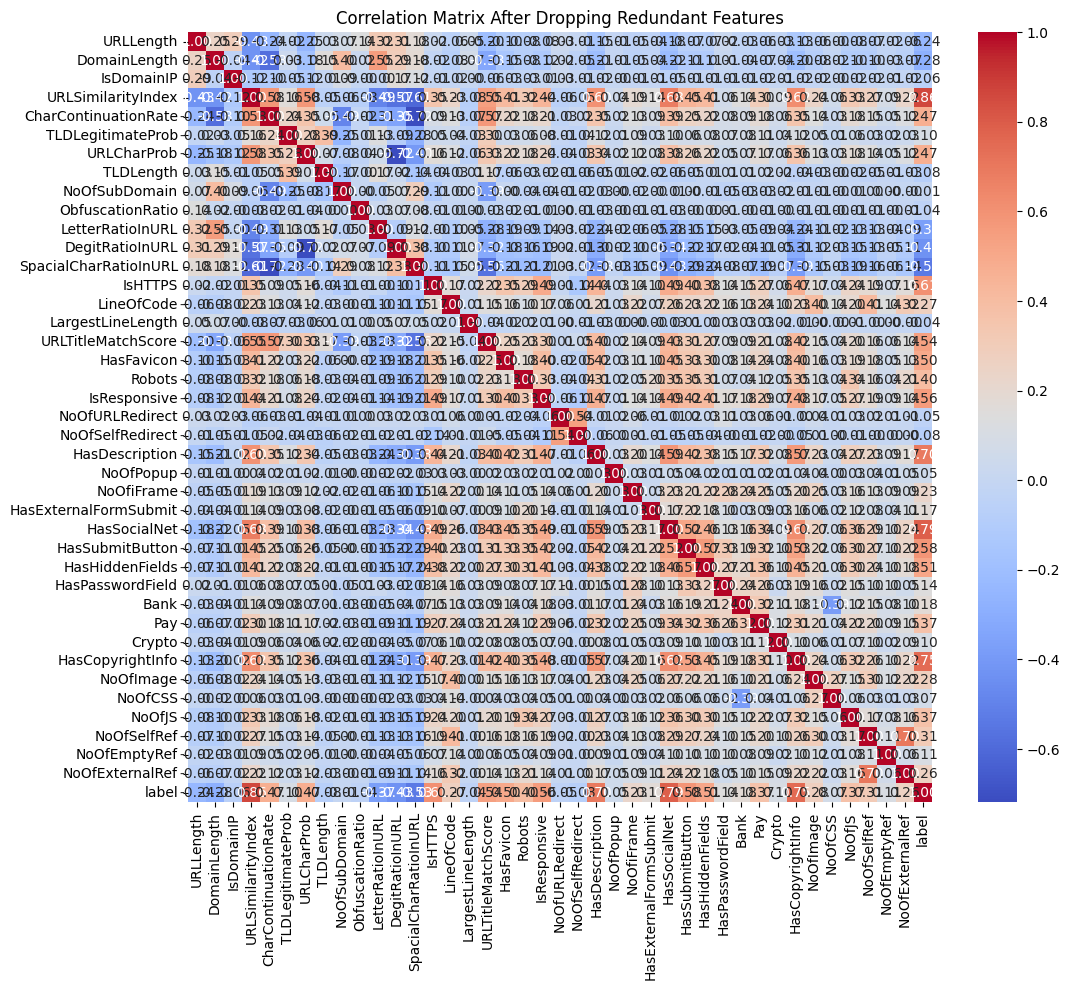

In [28]:
#be ensure we didn't miss any column to drop 
import seaborn as sns
import matplotlib.pyplot as plt

df_for_heatmap = df.select_dtypes(include=[np.number])
corr_matrix = df_for_heatmap.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix After Dropping Redundant Features')
plt.show()

for URLSimilartyindex
it would use the Levenshtein Distance algorithm to compare the input URL against a cached list of the Top 500 targeted brands (PayPal, Gmail, Netflix, etc.).

In [29]:
#we need to check similarity index feature importance with a simple model 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY URLSimilarityIndex
X_simple = df[['URLSimilarityIndex']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY SimilarityIndex: {accuracy_score(y, clf.predict(X_simple)):.4f}") #woow this is too high

Accuracy with ONLY SimilarityIndex: 0.9911


we need to drop because, the feature URLSimilarityIndex is not just correlated with the label; it is practically the definition of the label for this dataset.

In [30]:
df = df.drop(columns=['URLSimilarityIndex'])

In [31]:
# check the HasSocialNet.. to drop or not
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY HasSocialNetWord
X_simple = df[['HasSocialNet']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY HasSocialNet: {accuracy_score(y, clf.predict(X_simple)):.4f}")
#it is okey to keep HasSocialNet feature since lower than 0.9 accuracy

Accuracy with ONLY HasSocialNet: 0.8861


In [37]:
# check the urltitlematchscore.. to drop or not
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Test 1: Using ONLY URLTitleMatchScore
X_simple = df[['URLTitleMatchScore']]
y = df['label']

clf = DecisionTreeClassifier(max_depth=2) # Very simple model
clf.fit(X_simple, y)
print(f"Accuracy with ONLY URLTitleMatchScore: {accuracy_score(y, clf.predict(X_simple)):.4f}")
#it is okey to keep URLTitleMatchScore feature since lower than 0.9 accuracy

Accuracy with ONLY URLTitleMatchScore: 0.7736


Feature Creation

I look into data and talk with gemini (https://gemini.google.com/share/e89cd886988c)
 I find it there could be a good feature creations to help the model understand and for better visulazation with t-SNE...

In [32]:
df.columns

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'ObfuscationRatio', 'LetterRatioInURL', 'DegitRatioInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive',
       'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup',
       'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'TLD_Final', 'label'],
      dtype='object')

In [33]:
# 1. External Reference Ratio
df['External_Ref_Ratio'] = df['NoOfExternalRef'] / (df['NoOfSelfRef'] + df['NoOfEmptyRef'] + df['NoOfExternalRef'] + 1)

# 2. Dangerous Form Submission (Boolean interaction)
df['Unsafe_Form_Submit'] = ((df['HasPasswordField'] == 1) & (df['HasExternalFormSubmit'] == 1)).astype(int)

# 3. Sensitive Topic Aggregation
df['Sensitive_Keywords_Count'] = df['Bank'] + df['Pay'] + df['Crypto']

# 4. Domain Weight
df['Domain_Weight'] = df['DomainLength'] / df['URLLength']

Scaling 
(I will apply robust scaling if there is so much outlier 
if there is moderaable I will oick standartscaling
the reason I choose these 2 is centring my variable at 0 so PCA will performs better )

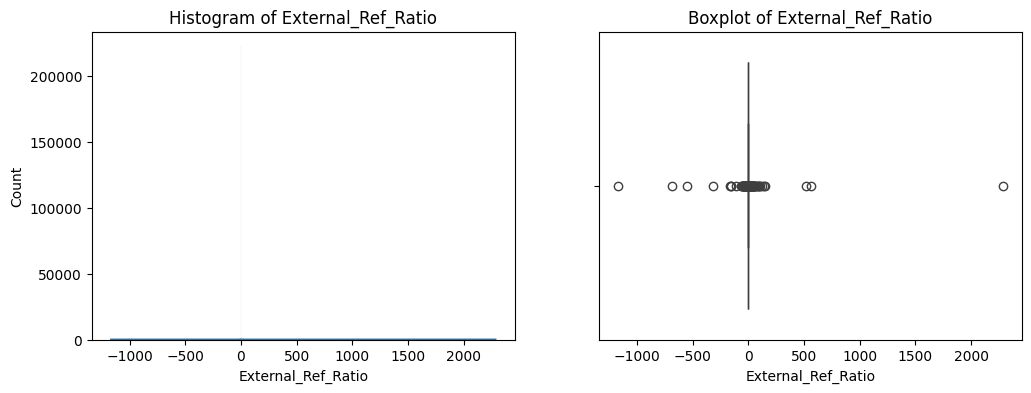

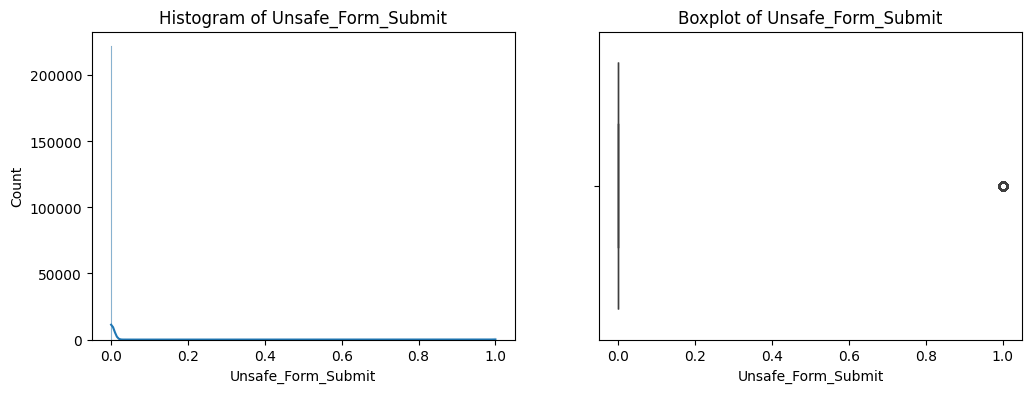

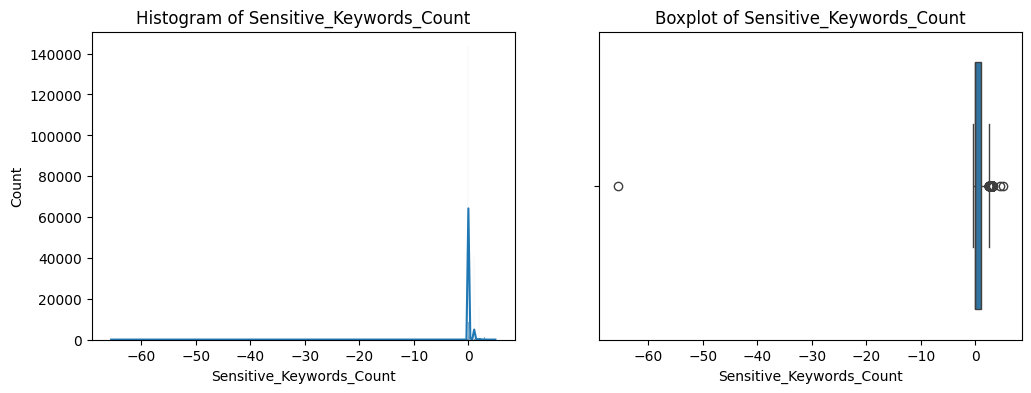

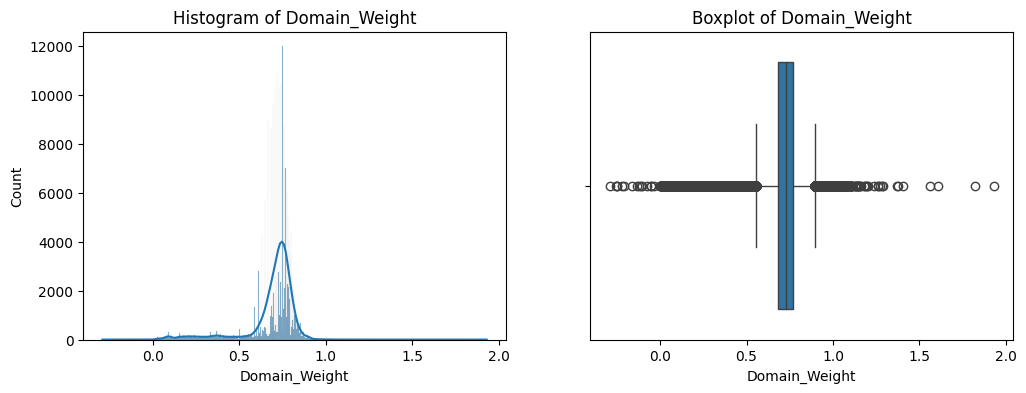

In [34]:
# I need to check their boxplot to see the distributions and apply scaling if needed
# I want to check individually also
for col in df[['External_Ref_Ratio','Unsafe_Form_Submit','Sensitive_Keywords_Count','Domain_Weight']]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    sns.boxplot(x=df[col], ax=axes[1])
    axes[0].set_title(f'Histogram of {col}')
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()

In [35]:
#check the Domain_Weight feature shapiro wilk test
from scipy.stats import shapiro
stat, p = shapiro(df['Domain_Weight'])
print(f'Shapiro-Wilk Test: Statistics={stat:.4f}, p-value={p:.4f}')

if p < 0.05:
    print("Domain_Weight feature is not normally distributed (reject H0)")
else:
    print("Domain_Weight feature is normally distributed (fail to reject H0)")

Shapiro-Wilk Test: Statistics=0.7219, p-value=0.0000
Domain_Weight feature is not normally distributed (reject H0)


/Users/akkus/Documents/GitHub/Phishing-URL--Website--Detection/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 224012.
  res = hypotest_fun_out(*samples, **kwds)


apply transformation Domain_Weigth

In [ ]:
#first I will apply power transform to make the distribution more gaussian like then I will apply robust scaler (I check on EDA part the distributions of these features are right skewed)
from sklearn.preprocessing import PowerTransformer, RobustScaler

#list if features to transform and scale
features_to_transform = ['URLLength','DomainLength','CharContinuationRate','TLDLegitimateProb','URLCharProb','LetterRatioInURL','SpacialCharRatioInURL',
                          'External_Ref_Ratio','Sensitive_Keywords_Count','Domain_Weight']
features_to_scale = ['URLLength','DomainLength','CharContinuationRate','TLDLegitimateProb','URLCharProb','LetterRatioInURL','SpacialCharRatioInURL',
                      'External_Ref_Ratio','Sensitive_Keywords_Count','Domain_Weight','Unsafe_Form_Submit']
# Apply Power Transform
power_transformer = PowerTransformer()
df[features_to_transform] = power_transformer.fit_transform(df[features_to_transform])
# Apply Robust Scaler
robust_scaler = RobustScaler()
df[features_to_scale] = robust_scaler.fit_transform(df[features_to_scale])